# Utilities for data 

> This module handles all communication-related functionalities, including message passing, event handling, and notifications.

In [ ]:
#| default_exp data.utils

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastcore import *
from fastcore.utils import *

In [1]:
#| export
import os

import numpy as np
import pandas as pd
import gdown

import torch
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as v2
import torch.nn.functional as F

In [2]:
#| export
def gdown_download_file(url: str, output: str= ".") -> None:
    """Downloads a file from the given URL and saves it to the specified output path.
    Args:
        url (str): The URL to download the file from.
        output (str): The path where the downloaded file should be saved.
    """
    gdown.download(url, output)

### CSI related

In [3]:
#| export
H_full_url = "https://drive.google.com/file/d/126gvv5GBgzgG21y19fza5vHBtFGxRWMq/view?usp=sharing"
valid_2d_url = "https://drive.google.com/file/d/1Dzj9joHNG434-ZQy3lIEBlscFvw_jH0w/view?usp=sharing"
csi_data_url = "https://drive.google.com/file/d/1bAQEiAvFU-oNeb_UuFO8nOD0NKaL08le/view?usp=sharing"


In [4]:
#| export
def get_h_full(H_full_url: str = H_full_url) -> np.ndarray:
    gdown_download_file(H_full_url, "H_full.npy")
    return np.load("H_full.npy")

def get_valid_2d(valid_2d_url: str = valid_2d_url) -> list:
    gdown_download_file(valid_2d_url, "valid_2d.npy")
    return [tuple(p) for p in np.load("valid_2d.npy")]

def get_csi_data(csi_data_url: str = csi_data_url) -> pd.DataFrame:
    gdown_download_file(csi_data_url, "csi_data.csv")
    return pd.read_csv("csi_data.csv")


In [5]:
#| hide
H_full   = get_h_full()
valid_2d = get_valid_2d()
N = len(valid_2d)

grid_to_idx  = {(gx, gy): i for i, (gx, gy) in enumerate(valid_2d)}
idx_to_grid  = {i: (gx, gy) for i, (gx, gy) in enumerate(valid_2d)}

Downloading...
From: https://drive.google.com/uc?id=126gvv5GBgzgG21y19fza5vHBtFGxRWMq
To: /home/ahmed/Ahmed-home/1- Projects/Research/Journal 2/code/c3jepa-wm/nbs/H_full.npy
100%|██████████| 275k/275k [00:00<00:00, 1.56MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Dzj9joHNG434-ZQy3lIEBlscFvw_jH0w
To: /home/ahmed/Ahmed-home/1- Projects/Research/Journal 2/code/c3jepa-wm/nbs/valid_2d.npy
100%|██████████| 2.22k/2.22k [00:00<00:00, 5.83MB/s]


In [8]:
#| export
def np_get_csi(H_full: np.ndarray, grid_to_idx: dict, tx_grid: tuple, rx_grid: tuple) -> np.ndarray:
    """
    Get CFR for a D2D link between two grid positions.
    tx_grid, rx_grid: (gx, gy) tuples
    Returns: complex array of shape [num_subcarriers]
    """
    i = grid_to_idx[tx_grid]
    j = grid_to_idx[rx_grid]
    assert i != j, f"tx and rx are the same position: {tx_grid}"
    return H_full[j, i]

def np_get_all_from(H_full: np.ndarray, grid_to_idx: dict, tx_grid: tuple) -> dict:
    """All channels from a given tx position to every other valid position."""
    i = grid_to_idx[tx_grid]
    return {
        idx_to_grid[j]: H_full[j, i]
        for j in range(N) if j != i
    }

def np_get_neighbors_csi(H_full: np.ndarray, grid_to_idx: dict, tx_grid: tuple, radius: int = 1) -> dict:
    """Only get CSI to nearby grid positions (useful for local D2D)."""
    gx, gy = tx_grid
    result = {}
    for rx_grid in valid_2d:
        rx_gx, rx_gy = rx_grid
        if rx_grid == tx_grid:
            continue
        if abs(rx_gx - gx) <= radius and abs(rx_gy - gy) <= radius:
            result[rx_grid] = np_get_csi(H_full, grid_to_idx, tx_grid, rx_grid)
    return result



In [ ]:
#| hide
h = np_get_csi(H_full, grid_to_idx, (2, 3), (5, 7))           # CFR from grid (2,3) -> (5,7)
all_h = np_get_all_from(H_full, grid_to_idx, (2, 3))          # all links from (2,3), keyed by (gx,gy)
nearby = np_get_neighbors_csi(H_full, grid_to_idx, tx_grid= (2, 3), radius=2)  # only close-by links
h

np.complex128(0.9006239175796509-0.4345993399620056j)

In [ ]:
#| hide
import numpy as np


def solve_closed_form_with_lookup(
    H_full,
    grid_to_idx,
    valid_locations,
    receiver_loc,
    target_snr_db=15.0,
    noise_power_dbm=-114.0,
):
    """
    Computes the closed-form linear mapping weights using a dynamic CSI lookup function.

    Parameters:
    -----------
    H_full, grid_to_idx :
        The specific data structures required by your custom `np_get_csi` function.
    valid_locations : list of tuples
        A list of your ~135 valid (x, y) coordinate tuples on the 13*13 grid.
    receiver_loc : tuple
        The constant (x, y) coordinate of your Base Station/Receiver (x2, y2).
    """
    M = len(valid_locations)

    # 1. Convert communication parameters to linear scale
    target_snr_lin = 10 ** (target_snr_db / 10.0)
    noise_power_lin = 10 ** ((noise_power_dbm - 30) / 10.0)

    # 2. Probe a single sample to dynamically read subcarrier dimension N
    sample_h = np_get_csi(H_full, grid_to_idx, valid_locations[0], receiver_loc)
    # Assumes sample_h returns a 1D complex array or a (2, N) real-split array
    # If it returns complex, we need to extract real/imag. Let's assume it's complex:
    N = len(sample_h)

    # Initialize our OLS data matrices
    # X will hold flattened Real/Imag components -> shape: (M, 2 * N)
    X = np.zeros((M, 2 * N))
    y = np.zeros((M, 1))

    # 3. Loop over your 135 locations to construct the dataset
    for idx, tx_loc in enumerate(valid_locations):
        # Fetch the complex CSI vector for the current link
        h_complex = np_get_csi(H_full, grid_to_idx, tx_loc, receiver_loc)

        # Deconstruct into structural Real and Imaginary parts
        h_real = np.real(h_complex)
        h_imag = np.imag(h_complex)

        # Flatten into a 1D row feature vector [Real_0, ..., Real_N, Imag_0, ..., Imag_N]
        X[idx, :] = np.concatenate([h_real, h_imag])

        # Calculate the Frobenius norm squared ||h||^2
        channel_gain_squared = np.sum(h_real**2) + np.sum(h_imag**2)

        # Calculate the exact physical target power for this specific grid coordinate
        y[idx, 0] = (target_snr_lin * noise_power_lin) / channel_gain_squared

    # 4. Solve the Closed-Form Normal Equation: w = (X^T * X + alpha*I)^(-1) * X^T * y
    XT_X = np.dot(X.T, X)
    XT_y = np.dot(X.T, y)

    # Ridge regularization parameter to ensure stable matrix inversion
    regularizer = 1e-6 * np.eye(2 * N)
    w_opt = np.linalg.solve(XT_X + regularizer, XT_y)

    return w_opt


# =============================================================================
# EXECUTABLE MOCK SETUP
# =============================================================================
if __name__ == "__main__":
    # Mocking your valid 135 locations from the 13x13 grid
    mock_valid_locations = [
        (x, y) for x in range(13) for y in range(13) if (x + y) % 2 == 0
    ][:135]
    mock_receiver = (6, 6)  # Base station right in the center of the grid

    # Mocking your custom lookup function environment variables
    H_full_mock = None
    grid_to_idx_mock = None

    # # Dummy placeholder function mimicking your exact signature
    # def np_get_csi(H_full, grid_to_idx, loc1, loc2):
    #     # Returns a mock 1-D complex vector across 64 subcarriers
    #     return np.random.randn(64) + 1j * np.random.randn(64)

    # Execute the solver
    w_optimal = solve_closed_form_with_lookup(
        H_full=H_full_mock,
        grid_to_idx=grid_to_idx_mock,
        valid_locations=mock_valid_locations,
        receiver_loc=mock_receiver,
        target_snr_db=15.0,
    )

    print(f"Dataset generated using lookup function across {len(mock_valid_locations)} grid coordinates.")
    print(f"Analytical Optimal Weights Computed. Shape: {w_optimal.shape}")

In [ ]:
#| export

# Assuming df has columns: tx_grid, rx_grid, csi
# and tuples are stored as (gx, gy)

# Build a lookup index from the dataframe once
def build_csi_index(csi_data: pd.DataFrame) -> dict:
    return {
        (tx, rx): csi
        for tx, rx, csi in zip(csi_data["tx_grid"], csi_data["rx_grid"], csi_data["csi"])
    }

def df_get_csi(csi_data: pd.DataFrame, tx_grid: tuple, rx_grid: tuple) -> complex:
    """Get CSI for a single tx->rx pair."""
    # Normalize to plain int tuples (in case of np.int64)
    csi_index = build_csi_index(csi_data)
    tx = (int(tx_grid[0]), int(tx_grid[1]))
    rx = (int(rx_grid[0]), int(rx_grid[1]))
    assert tx != rx, f"tx and rx are the same position: {tx}"
    print((tx, rx))
    return csi_index[(tx, rx)]

def df_get_all_from(csi_data: pd.DataFrame, tx_grid: tuple) -> pd.DataFrame:
    """All channels from a given tx position to every other valid position."""
    tx = (int(tx_grid[0]), int(tx_grid[1]))
    return csi_data[csi_data["tx_grid"].apply(lambda t: (int(t[0]), int(t[1])) == tx)]

def df_get_neighbors_csi(csi_data: pd.DataFrame, tx_grid: tuple, radius: int = 1) -> pd.DataFrame:
    """Only get CSI to nearby grid positions."""
    tx = (int(tx_grid[0]), int(tx_grid[1]))
    gx, gy = tx

    def is_neighbor(rx):
        rx = (int(rx[0]), int(rx[1]))
        return rx != tx and abs(rx[0] - gx) <= radius and abs(rx[1] - gy) <= radius

    mask = (
        csi_data["tx_grid"].apply(lambda t: (int(t[0]), int(t[1])) == tx) &
        csi_data["rx_grid"].apply(is_neighbor)
    )
    return csi_data[mask]

In [ ]:
# #| hide
# csi_data = get_csi_data()
# h2 = df_get_csi(csi_data, (2, 3), (5, 7))           # CFR from grid (2,3) -> (5,7)
# all_h2 = df_get_all_from(csi_data, (2, 3))          # all links from (2,3), keyed by (gx,gy)
# nearby_2 = df_get_neighbors_csi(csi_data, tx_grid= (2, 3), radius=2)  # only close-by links
# h2

### H5 dataset utilities

In [ ]:
#| export
import os
import glob

import numpy as np
import h5py


In [ ]:
#| export
def save_rollout_hdf5(rollout_idx, save_dict, data_dir):
    """Save one rollout as a group inside a shared HDF5 file."""
    os.makedirs(data_dir, exist_ok=True)
    h5_path = os.path.join(data_dir, "dataset.h5")

    with h5py.File(h5_path, 'a') as f:   # 'a' = append mode
        grp = f.create_group(f"rollout_{rollout_idx:06d}")
        for k, v in save_dict.items():
            grp.create_dataset(
                k,
                data=v if isinstance(v, np.ndarray) else np.asarray(v),
                compression="lz4",   # fast compression, good for uint8 images
            )

def merge_npz_to_hdf5(data_dir, out_path):
    files = sorted(glob.glob(os.path.join(data_dir, "rollout_*.npz")))

    merged = 0
    skipped = 0

    with h5py.File(out_path, "w") as h5:
        for fpath in files:

            try:
                with np.load(fpath, allow_pickle=True) as data:

                    # Force validation of every member
                    for k in data.files:
                        _ = data[k]

                    name = os.path.splitext(os.path.basename(fpath))[0]
                    grp = h5.create_group(name)

                    for k in data.files:
                        arr = data[k]

                        if arr.ndim == 0:
                            grp.attrs[k] = arr.item()
                        else:
                            grp.create_dataset(
                                k,
                                data=arr,
                                compression="gzip",
                                compression_opts=4,
                            )

                merged += 1

            except Exception as e:
                skipped += 1
                print(f"Skipping {fpath}: {e}")

    print(f"Merged  {merged} rollouts")
    print(f"Skipped {skipped} corrupted rollouts")
    

### Various utils

In [ ]:
#| export
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch
import einops
def show_batch(dl, denormalize_tf, save_to="./batch.png"):
    dataiter = iter(dl)
    data = next(dataiter)
    images = data['agent_0']['obs']

    if images.ndim == 5:
        images = einops.rearrange(images, 'b s c h w -> (b s) c h w')
        print(images.shape)

    print(f"Max pixel value: {images.max().item()}")
    print(f"Mean pixel value: {images.mean().item()}")
    images = denormalize_tf(images) if denormalize_tf is not None else images
    print(f"After denormalization:")
    print("+"*20)
    print(f"Max pixel value: {images.max().item()}")
    print(f"Mean pixel value: {images.mean().item()}")
    images = torch.clamp(images, 0, 1)

    grid_img = torchvision.utils.make_grid(images, nrow=8) # nrow controls how many images per row
    np_grid = torch.einsum('chw->hwc', grid_img).numpy()


    plt.figure(figsize=(15, 10))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.savefig(save_to, bbox_inches='tight')
    plt.savefig("pdf.pdf", bbox_inches='tight')
    plt.show()

torch.Size([40, 3, 42, 42])
Max pixel value: 1.0
Mean pixel value: -0.8795627355575562
After denormalization:
++++++++++++++++++++
Max pixel value: 1.0
Mean pixel value: 0.060218606144189835


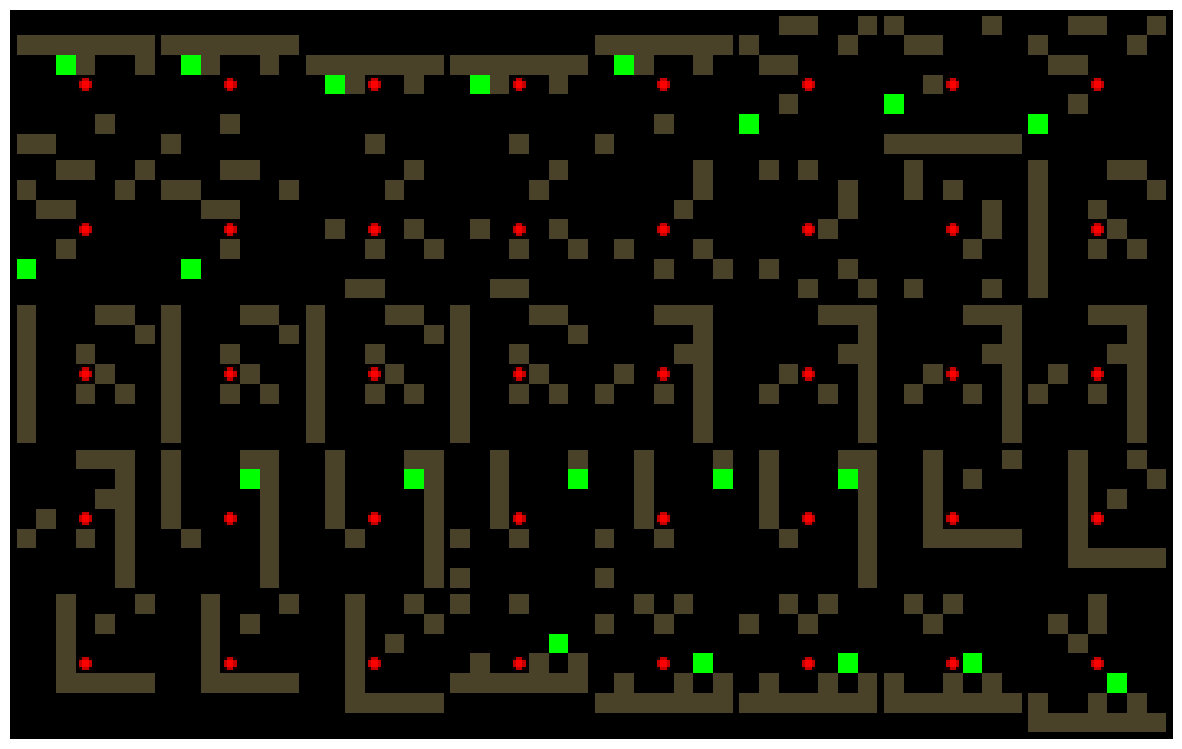

In [ ]:
# #| hide
# show_batch(dl, denormalize_tf, save_to="../batch.png")

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()